# ３章１節２項 全域閾値手法

## 概要
SAR画像から水域を抽出するための全域閾値手法を実装します。
Valley Emphasis法を用いて最適な閾値を自動的に決定し、画像を水域と非水域に2値化します。

## 使用データ

| 項目 | 情報 |
| ---- | ---- |
| 衛星 | STRIX-1 |
| データパス | /work/data/water/ |
| データ形式 | GeoTIFF (VV偏波、SM-GRD) |
| 撮影日時 | 2022年12月12日 19:27:10 UTC |
| 画像クレジット | © Synspective Inc. |

In [6]:
# 必要なライブラリのインポート
import os
import warnings

import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt
import japanize_matplotlib

# 警告メッセージを非表示
warnings.filterwarnings('ignore')

In [7]:
# 入力データと出力先のパス設定
PATH_INPUT = '/work/data/water/'
PATH_OUTPUT = '/work/outputs/water/'

# 入力ファイル名
INPUT_FILENAME = 'IMG-VV-STRIX1-20221212T192710Z-SMGRD.tif'

# 校正係数（メタ情報で設定されている値）
CALIBRATION_FACTOR = 251.2

# 出力ディレクトリが存在しない場合は作成
os.makedirs(PATH_OUTPUT, exist_ok=True)

# 元画像の読み込みと確認

In [8]:
# 画像パスの設定
IMG_PATH = os.path.join(PATH_INPUT, INPUT_FILENAME)

# 画像の読み込みとシグマ値への変換
with rio.open(IMG_PATH) as src:
    img = src.read(1).astype(np.float32)
    # DN値からシグマノート値への変換
    sigma = (img ** 2) / (CALIBRATION_FACTOR ** 2)
    sigma[sigma == 0] = np.nan
    sigma_sqrt = np.sqrt(sigma)

print(f'画像サイズ: {sigma_sqrt.shape[0]} × {sigma_sqrt.shape[1]} ピクセル')
print(f'データ型: {sigma_sqrt.dtype}')

画像サイズ: 16682 × 7643 ピクセル
データ型: float32


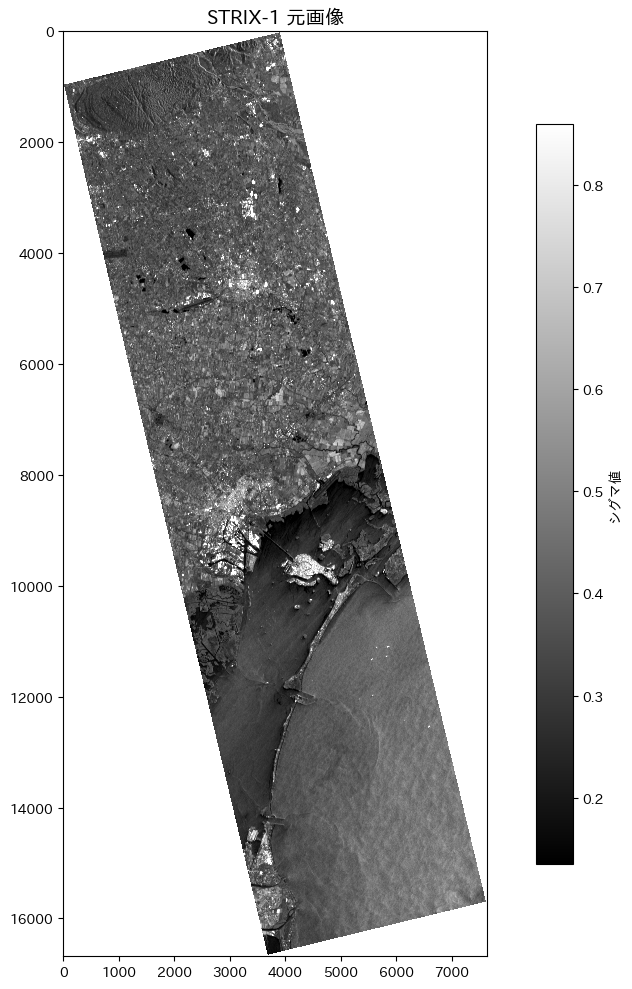

シグマ値の範囲: 0.0040 - 167.7309
2-98パーセンタイル: 0.1354 - 0.8599


In [9]:
# 可視化用のパーセンタイル値を計算
p2, p98 = np.nanpercentile(sigma_sqrt, [2, 98])

# 元画像を可視化
plt.figure(figsize=(10, 10))
plt.imshow(sigma_sqrt, cmap='gray', vmin=p2, vmax=p98)
plt.title('STRIX-1 元画像', fontsize=14)
plt.colorbar(label='シグマ値', shrink=0.8)
plt.savefig(os.path.join(PATH_OUTPUT, 'figure31.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

print(f'シグマ値の範囲: {np.nanmin(sigma_sqrt):.4f} - {np.nanmax(sigma_sqrt):.4f}')
print(f'2-98パーセンタイル: {p2:.4f} - {p98:.4f}')

# 解析領域の切り出し

In [10]:
# 出力ファイルパス
OUTPUT_CLIP = os.path.join(PATH_OUTPUT, 'IMG-VV-STRIX1-20221212T192710Z-SMGRD_clip.tif')

# 画像の読み込みと切り取り
with rio.open(IMG_PATH) as src:
    out_meta = src.meta.copy()
    
    img = src.read(1).astype(np.float32)
    sigma = (img ** 2) / (CALIBRATION_FACTOR ** 2)
    sigma[sigma == 0] = np.nan
    
    # 解析対象領域のウィンドウを設定
    window = rio.windows.Window(col_off=2040, row_off=4100, width=230, height=220)
    transform = rio.windows.transform(window, src.transform)
    
    # メタデータの更新
    out_meta.update({
        "driver": "GTiff",
        "height": window.height,
        "width": window.width,
        "transform": transform,
        "dtype": 'float32'
    })

    # ウィンドウ領域を切り出し
    img_clip = sigma[window.row_off:window.row_off+window.height, 
                     window.col_off:window.col_off+window.width]

# 切り出した画像を保存
with rio.open(OUTPUT_CLIP, "w", **out_meta) as dest:
    dest.write(img_clip, 1)

print(f'切り出し領域: {window.width} × {window.height} ピクセル')
print(f'保存先: {OUTPUT_CLIP}')

切り出し領域: 230 × 220 ピクセル
保存先: /work/outputs/water/IMG-VV-STRIX1-20221212T192710Z-SMGRD_clip.tif


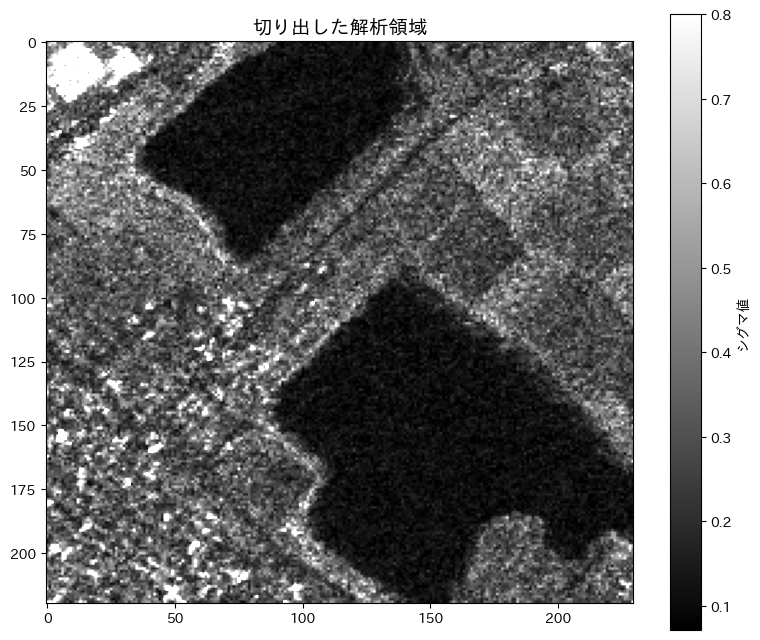

In [11]:
# 切り取った画像の読み込みと可視化
with rio.open(OUTPUT_CLIP) as src:
    sigma_clip = src.read(1).astype(np.float32)
    sigma_clip_sqrt = np.sqrt(sigma_clip)
    
p2, p98 = np.nanpercentile(sigma_clip_sqrt, [2, 98])

plt.figure(figsize=(8, 8))
plt.imshow(sigma_clip_sqrt, cmap='gray', vmin=p2, vmax=p98)
plt.title('切り出した解析領域', fontsize=14)
plt.colorbar(label='シグマ値', shrink=0.8)
plt.savefig(os.path.join(PATH_OUTPUT, 'figure32.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

# 画像のdB変換とヒストグラム分析

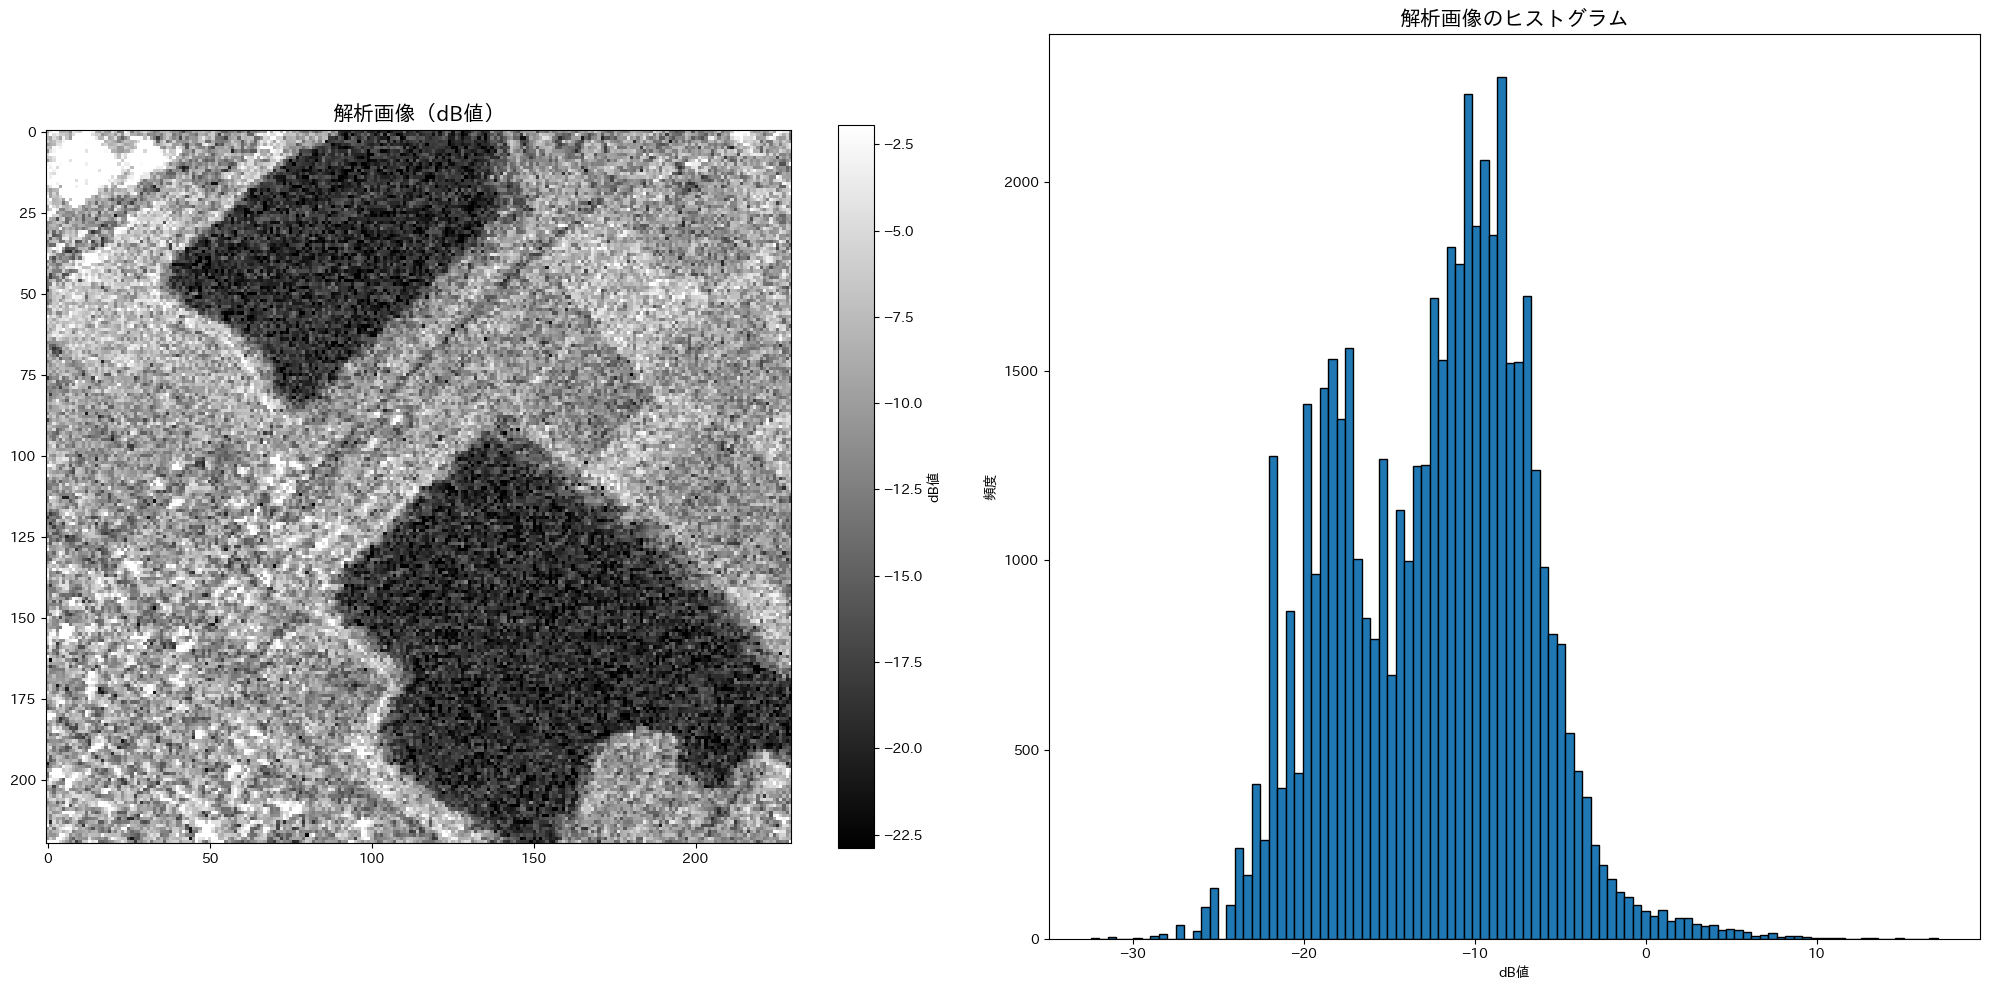

dB値の範囲: -32.44 - 17.08


In [12]:
# 切り取った画像をdB値に変換
with rio.open(OUTPUT_CLIP) as src:
    img = src.read(1).astype(np.float32)
    img_dB = 10 * np.log10(img)

# 可視化用のパーセンタイル値を計算
p2, p98 = np.nanpercentile(img_dB, [2, 98])

# 解析画像とヒストグラムを表示
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(img_dB, cmap='gray', vmin=p2, vmax=p98)
plt.title('解析画像（dB値）', fontsize=15)
plt.colorbar(label='dB値', shrink=0.8)

plt.subplot(1, 2, 2)
plt.hist(img_dB[~np.isnan(img_dB)].flatten(), bins=100, edgecolor='black')
plt.title('解析画像のヒストグラム', fontsize=15)
plt.xlabel('dB値')
plt.ylabel('頻度')

plt.savefig(os.path.join(PATH_OUTPUT, 'figure33.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

print(f'dB値の範囲: {np.nanmin(img_dB):.2f} - {np.nanmax(img_dB):.2f}')

# Valley Emphasis法による閾値決定

In [13]:
def valley_emphasis(image):
    """
    Valley Emphasis法を用いて最適な閾値を自動決定する関数
    
    ヒストグラムの谷部分を強調することで、2つのクラス（水域と非水域）を
    分離するための最適な閾値を自動的に決定します。
    
    Parameters:
    -----------
    image : ndarray
        入力画像（2次元配列）
    
    Returns:
    --------
    threshold : float
        最適な閾値
    """
    # 画像の最小値と最大値を取得（NaNを除く）
    min_val = np.nanmin(image)
    max_val = np.nanmax(image)

    # ヒストグラムのビン数を設定
    bins = int((max_val - min_val) * 10) + 1
    counts, bin_edges = np.histogram(image[~np.isnan(image)], bins=bins, range=(min_val, max_val))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    total = np.sum(~np.isnan(image))
    
    # 全体の平均値を計算
    sum_val = np.sum(bin_centers * counts / total)
    
    var_max = 0
    threshold = 0
    
    omega_1 = 0
    omega_2 = 0
    mu_k = 0
    
    # 各閾値候補について分散を計算
    for t in range(bins):
        omega_1 += counts[t] / total
        omega_2 = 1 - omega_1
        mu_k += bin_centers[t] * counts[t] / total
        
        # クラス1の平均値
        if omega_1 == 0:
            mu_1 = 0
        else:
            mu_1 = mu_k / omega_1
        
        # クラス2の平均値
        if omega_2 == 0:
            mu_2 = 0
        else:
            mu_2 = (sum_val - mu_k) / omega_2
        
        # Valley Emphasisの評価関数
        current_var = (1 - counts[t] / total) * (omega_1 * (mu_1 ** 2) + omega_2 * (mu_2 ** 2))
        
        # 最大分散を更新
        if current_var > var_max:
            var_max = current_var
            threshold = bin_centers[t]
    
    return threshold

In [14]:
# Valley Emphasis法を用いて閾値を決定
threshold = valley_emphasis(img_dB)

print('=' * 60)
print('Valley Emphasis法による閾値決定結果')
print('=' * 60)
print(f'最適閾値: {threshold:.4f} dB')
print('=' * 60)

Valley Emphasis法による閾値決定結果
最適閾値: -13.4206 dB


# 2値化結果の可視化と保存

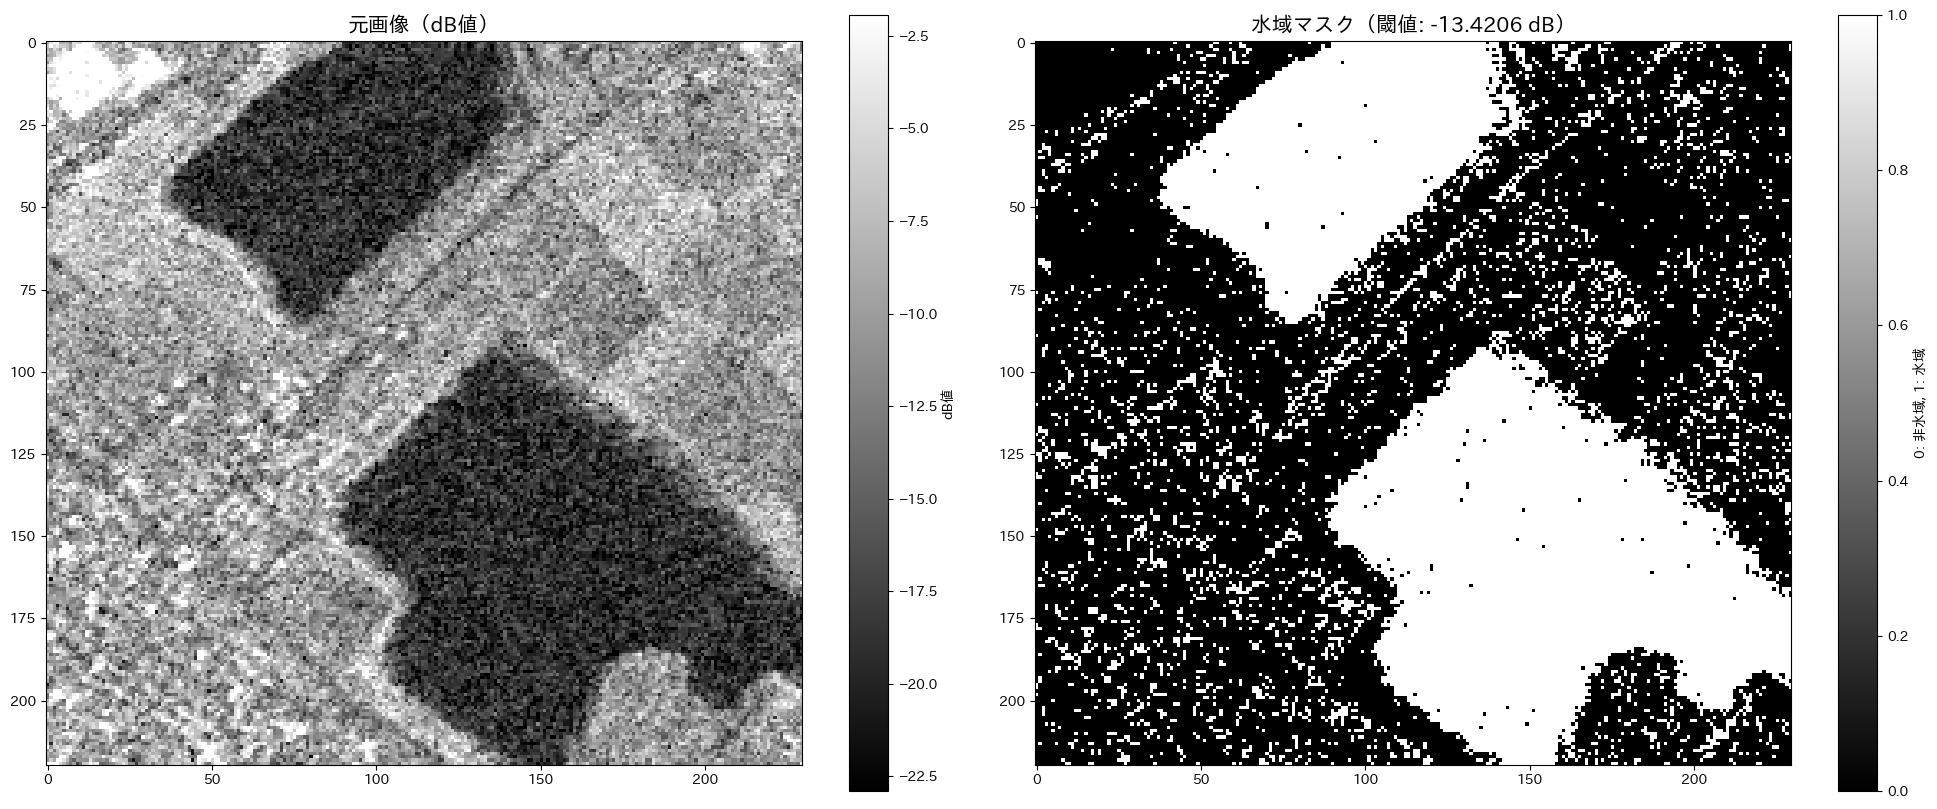


水域の割合: 39.51%


In [ ]:
# 閾値を用いて2値化（閾値より小さい値を水域とする）
water_mask = np.where(img_dB < threshold, 1, 0)

# 2値化結果を可視化
plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(img_dB, cmap='gray', vmin=p2, vmax=p98)
plt.title('元画像（dB値）', fontsize=15)
plt.colorbar(label='dB値', shrink=0.8)

plt.subplot(1, 2, 2)
plt.imshow(water_mask, cmap='gray')
plt.title(f'水域マスク（閾値: {threshold:.4f} dB）', fontsize=15)
plt.colorbar(label='0: 非水域, 1: 水域', shrink=0.8)

plt.savefig(os.path.join(PATH_OUTPUT, 'figure34.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()